In [1]:
# Load the car prices dataset
import pandas as pd
df = pd.read_csv(r"carprices.csv")
print(f"Dataset shape: {df.shape}")
df.head()

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4


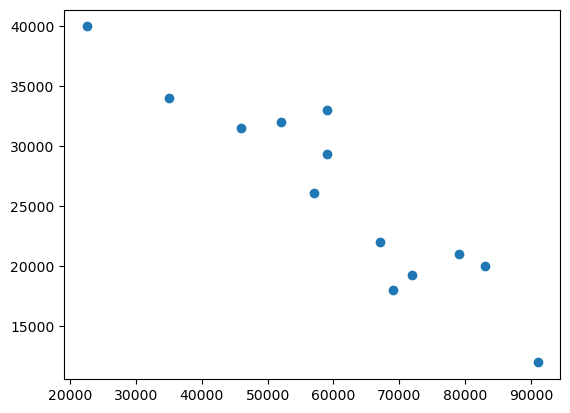

In [2]:
import matplotlib.pyplot as plt

# Higher mileage generally means a lower sell price
plt.scatter(df['Mileage'], df['Sell Price($)'], color='steelblue')
plt.xlabel('Mileage')
plt.ylabel('Sell Price ($)')
plt.title('Mileage vs Sell Price')
plt.tight_layout()
plt.show()

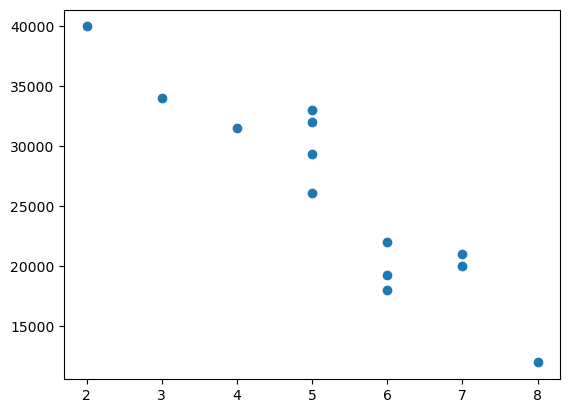

In [3]:
# Older cars tend to sell for less
plt.scatter(df['Age(yrs)'], df['Sell Price($)'], color='tomato')
plt.xlabel('Age (years)')
plt.ylabel('Sell Price ($)')
plt.title('Car Age vs Sell Price')
plt.tight_layout()
plt.show()

Both scatter plots show a clear negative linear relationship between the features (Mileage, Age) and the Sell Price.
This makes **Multivariate Linear Regression** a suitable model here.

In [4]:
X= df[['Mileage','Age(yrs)']]
Y= df['Sell Price($)']


In [5]:
X

,Mileage,Age(yrs)
0,69000,6
1,35000,3
2,57000,5
3,22500,2
4,46000,4
5,59000,5
6,52000,5
7,72000,6
8,91000,8
9,67000,6


In [6]:
from sklearn.model_selection import train_test_split


In [15]:
# test_size=0.2 → 20% of data goes to test set, 80% to training
# random_state=10 → fixes the random seed so the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=10)



In [16]:
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

3

In [17]:
X_train

,Mileage,Age(yrs)
6,52000,5
8,91000,8
2,57000,5
12,59000,5
5,59000,5
10,83000,7
1,35000,3
0,69000,6
4,46000,4
9,67000,6


In [18]:
# LinearRegression fits a line: Price = w1*Mileage + w2*Age + bias
from sklearn.linear_model import LinearRegression
clf = LinearRegression()

In [19]:
clf.fit(X_train,y_train)

LinearRegression()

In [20]:
# Predicted prices for the 3 test samples
predictions = clf.predict(X_test)
print("Predicted prices:", predictions.round(2))
print("Actual prices   :", y_test.values)

array([41842.49106079, 22531.68057211, 18423.93325387])

In [21]:
y_test

3     40000
7     19300
11    21000
Name: Sell Price($), dtype: int64

In [22]:
# R² score: 1.0 = perfect, 0.0 = no better than predicting the mean
score = clf.score(X_test, y_test)
print(f"R² score on test set: {score:.4f}")
print(f"Model coefficients  : Mileage={clf.coef_[0]:.4f}, Age={clf.coef_[1]:.4f}")
print(f"Intercept           : {clf.intercept_:.2f}")

0.9224816911971745